# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/pathakadithi/flyrank-ml-internship/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

# Content Opportunity Scoring for Search-Driven Content Review

### A Decision-Support Approach Using Anonymized FlyRank Search Data

## Abstract

This research asks whether observable search-performance signals can be used to prioritize pages for content review when review capacity is limited. The analysis uses anonymized FlyRank warehouse data and five historical features covering impressions, clicks, CTR, and search position. A Logistic Regression model was trained using the Week-4 baseline-defined opportunity label and evaluated using both a random stratified split and a client-grouped validation check. The model achieved an F1 score of 0.6141 under the random split and 0.6095 under client-grouped validation, with recall close to 1.0 in both checks. These results provide directional evidence that a learned scoring approach can approximate a rule-based content-opportunity policy, but they do not prove future recovery, causal refresh impact, or Google's ranking behavior.

## Introduction / Problem Statement

Content teams can have more pages available for review than they can realistically inspect. The practical challenge is therefore to decide which pages deserve attention first.

This capstone focuses on the **Refresh / Content Opportunity Scoring** lane. The objective is to build a repeatable workflow that uses observable historical search-performance signals to prioritize pages for content review.

The Week-4 work provides a rule-based content-opportunity baseline. The Week-5 work then uses machine learning to learn the baseline-defined opportunity condition from historical performance features. A later client-grouped validation check is used to examine whether the observed performance remains similar when the model is evaluated on previously unseen clients.

The intended output is a ranked review workflow that helps allocate limited content-review effort.

This work is decision-support rather than an automated content decision system. It does not claim that a refresh will cause traffic recovery, that a particular intervention will improve search performance, or that the model identifies Google's internal ranking factors.

## 1. Question

*The research question and the decision it supports.*

In [18]:
question = """
Can observable search-performance signals be used to prioritize pages
for content review when review capacity is limited?

The goal is to build a repeatable decision-support workflow that ranks
content opportunities using observable historical search signals.
"""

print(question)


Can observable search-performance signals be used to prioritize pages
for content review when review capacity is limited?

The goal is to build a repeatable decision-support workflow that ranks
content opportunities using observable historical search signals.



### Research Question

Can observable search-performance signals be used to prioritize pages for content review when review capacity is limited?

The goal is to help a reviewer decide which pages should be inspected first.

This is a decision-support problem. The analysis does not claim that refreshing a page will cause recovery or improved search performance.

## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

In [19]:
data_summary = {
    "release": "flyrank_pseudonymized_warehouse_release_v20260703",
    "daily_table_rows": 78_835_655,
    "query_table_rows": 2_414_248,
    "content_items": 519_606,
    "date_start": "2025-01-27",
    "date_end": "2026-06-30"
}

for key, value in data_summary.items():
    print(f"{key}: {value}")

release: flyrank_pseudonymized_warehouse_release_v20260703
daily_table_rows: 78835655
query_table_rows: 2414248
content_items: 519606
date_start: 2025-01-27
date_end: 2026-06-30


### Data Used

This capstone uses the anonymized FlyRank warehouse release:

`flyrank_pseudonymized_warehouse_release_v20260703`

The analysis uses the following warehouse tables:

- `fact_content_daily_performance`
- `fact_content_query_90d`
- `dim_content`
- `dim_clients`

The daily performance table contains 78,835,655 rows, and the query table contains 2,414,248 rows. The release contains 519,606 content items.

The available daily performance window used for this analysis is 2025-01-27 through 2026-06-30.

The analysis excludes incomplete recent data where appropriate and does not publish client names, domains, URLs, private queries, credentials, or raw exports.

## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

### Methodology

This capstone builds on the Week-4 rule-based baseline and the Week-5 machine-learning model.

#### 1. Baseline

The Week-4 baseline creates a content-opportunity score using observable historical search-performance signals.

The baseline identifies pages that may deserve content review based on signals such as search visibility, CTR, position, and recent performance.

#### 2. Features

The Week-5 model uses the following historical features:

- `impressions_90d`
- `clicks_90d`
- `ctr`
- `avg_position_90d`
- `avg_position_last30`

These features represent observable historical search-performance signals.

#### 3. Label Definition

The target variable is `baseline_action`.

A row receives a positive label when:

`baseline_score > 0`

and otherwise receives a negative label.

Therefore, the Week-5 model learns to reproduce the opportunity definition created by the Week-4 baseline. It should not be interpreted as an independent prediction of future traffic recovery or refresh success.

#### 4. Model

The Week-5 model uses Logistic Regression.

The model combines the historical features to estimate the baseline-defined opportunity class.

#### 5. Initial Validation

The Week-5 model uses an 80/20 random stratified train/test split with `random_state=42`.

Stratification preserves the class distribution between training and test data.

#### 6. Client-Grouped Validation

A stricter validation check was subsequently performed using client-grouped splitting.

Clients in the training set were kept separate from clients in the test set.

This tests whether the observed model performance remains similar when the model is evaluated on previously unseen clients.

#### 7. Leakage Checks

The features are restricted to observable historical performance signals.

The analysis does not use client names, domains, private queries, credentials, or future refresh outcomes as model features.

Because the target is derived from the Week-4 baseline rule, the model is interpreted as learning the baseline opportunity policy rather than predicting an independently observed future outcome.

#### 8. Interpretation

The model is used for decision support and prioritization.

A high-scoring page should be treated as a candidate for human review, not as proof that the page requires a refresh or that a refresh will improve performance.

In [20]:
features = [
    "impressions_90d",
    "clicks_90d",
    "ctr",
    "avg_position_90d",
    "avg_position_last30"
]

print("Model features:")
for feature in features:
    print("-", feature)

print("\nModel: Logistic Regression")
print("Target: baseline_action")
print("Initial validation: 80/20 stratified split")
print("Additional robustness check: client-grouped split")

Model features:
- impressions_90d
- clicks_90d
- ctr
- avg_position_90d
- avg_position_last30

Model: Logistic Regression
Target: baseline_action
Initial validation: 80/20 stratified split
Additional robustness check: client-grouped split


## 4. Results

*Model vs baseline on the same split. The honest table.*

### Results Overview

The Week-5 Logistic Regression model was evaluated using an 80/20 random stratified split.

A later client-grouped validation check was also performed to test whether the result remained similar when clients in the test set were not present in the training set.

Because the target is derived from the Week-4 baseline rule, these metrics measure agreement with the baseline-defined opportunity label. They should not be interpreted as proof of future performance recovery or refresh impact.

In [21]:
import pandas as pd

random_split_results = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1"],
    "Score": [0.952803, 0.443195, 0.999504, 0.614092]
})

display(random_split_results)

,Metric,Score
0,Accuracy,0.952803
1,Precision,0.443195
2,Recall,0.999504
3,F1,0.614092


In [22]:
grouped_results = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1"],
    "Score": [0.952212, 0.438364, 0.999571, 0.609452]
})

display(grouped_results)

,Metric,Score
0,Accuracy,0.952212
1,Precision,0.438364
2,Recall,0.999571
3,F1,0.609452


In [23]:
comparison = pd.DataFrame({
    "Validation": [
        "W05 Random Stratified",
        "Client Grouped"
    ],
    "Accuracy": [
        0.952803,
        0.952212
    ],
    "Precision": [
        0.443195,
        0.438364
    ],
    "Recall": [
        0.999504,
        0.999571
    ],
    "F1": [
        0.614092,
        0.609452
    ]
})

display(comparison)

,Validation,Accuracy,Precision,Recall,F1
0,W05 Random Stratified,0.952803,0.443195,0.999504,0.614092
1,Client Grouped,0.952212,0.438364,0.999571,0.609452


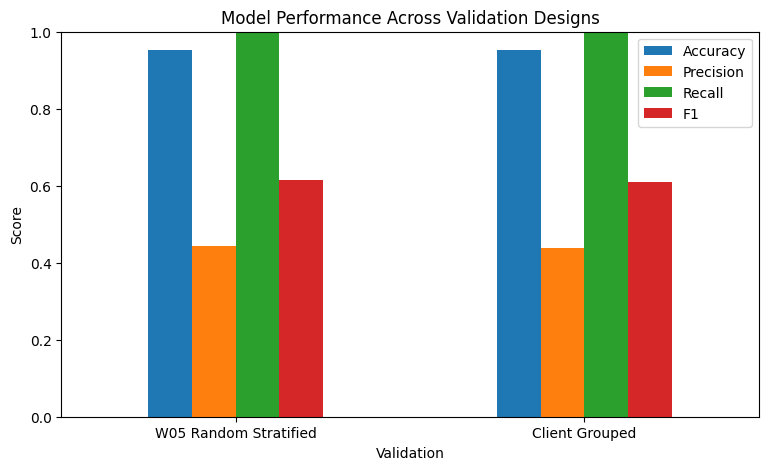

In [24]:
import matplotlib.pyplot as plt

comparison_plot = comparison.set_index("Validation")

comparison_plot[["Accuracy", "Precision", "Recall", "F1"]].plot(
    kind="bar",
    figsize=(9, 5)
)

plt.ylim(0, 1)
plt.ylabel("Score")
plt.title("Model Performance Across Validation Designs")
plt.xticks(rotation=0)
plt.legend()
plt.show()

### Interpretation

The initial W05 random stratified validation produced an F1 score of 0.6141.

The client-grouped validation produced an F1 score of 0.6095.

The difference between the two F1 scores is small. Accuracy also remained very similar, changing from 0.9528 to 0.9522.

Recall remained extremely high in both validation designs, while precision was substantially lower. This means the model captures nearly all examples belonging to the baseline-defined positive class, but a meaningful number of predicted opportunities do not match the baseline label.

The client-grouped result provides a useful robustness check because the model was evaluated on clients that were not present in training.

However, these results measure performance against the baseline-derived label. They do not demonstrate that the model predicts future traffic recovery, that refreshing content will improve performance, or that the model has discovered Google's ranking algorithm.

### Error Analysis

Under the W05 random split, the main model disagreement was false positives: 22,780 rows were predicted as opportunities but were not marked as opportunities by the W04 baseline rule.

These should be interpreted as disagreements with the baseline policy rather than proof that the pages are genuinely poor-performing.

The relatively lower precision compared with recall suggests that the resulting review queue should be treated as a candidate list for human inspection rather than an automatic action list.

## 5. Limitations & Honest Framing

This analysis has several important limitations.

1. **The target is baseline-derived.**  
   The Week-5 model learns the `baseline_action` defined by the Week-4 rule. Therefore, the model should not be interpreted as an independently validated prediction of future traffic, ranking recovery, or refresh success.

2. **The analysis is observational.**  
   The results describe relationships and model performance within the available data. They do not establish that changing or refreshing a page will cause improved search performance.

3. **Precision is lower than recall.**  
   The model has very high recall but substantially lower precision. Some pages identified as opportunities will therefore not match the baseline-defined positive class.

4. **Validation has limitations.**  
   The initial Week-5 evaluation used a random stratified split. A later client-grouped validation check was used as a stricter robustness test. Neither design proves performance on every future client or future time period.

5. **The features are limited.**  
   The model uses a small set of historical search-performance signals. Other factors affecting content performance may not be represented.

6. **Ranking is for review prioritization.**  
   A high-priority page should be treated as a candidate for human review rather than an automatic recommendation to refresh, rewrite, merge, or remove the page.

7. **No causal or Google-algorithm claim is made.**  
   This research does not claim to identify Google's internal ranking factors, prove how Google's algorithm works, or demonstrate that a content refresh causes recovery.

### Honest framing

The strongest conclusion supported by this analysis is:

> The learned model provides a repeatable way to approximate the Week-4 content-opportunity policy using observable historical signals, and its performance remains broadly similar under a client-grouped validation check.

The result should therefore be described as **directional evidence and decision-support**, not causal evidence or a guarantee of future performance.

## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

## 6. Ranked Recommendations

The model is intended to support a prioritized content-review workflow. The recommendations below translate the observed signals and model output into practical review actions.

The priority order is an action playbook, not a claim that these categories represent guaranteed future performance outcomes.

### Priority 1 — Model Decline Risk

**Action:** Review pages receiving a strong model opportunity signal.

**Reason:** The model identifies these pages as matching the baseline-defined opportunity condition.

**Review:** Check recent performance, search intent alignment, content freshness, and whether the page still satisfies the user's likely intent.

---

### Priority 2 — Visible Model Opportunity

**Action:** Review pages with meaningful search visibility that also receive an opportunity signal.

**Reason:** These pages have enough observable visibility for a content review to be useful.

**Review:** Inspect content quality, relevance, structure, and opportunities to improve the page's usefulness.

---

### Priority 3 — CTR Review Candidate

**Action:** Review pages with meaningful impressions but relatively weak CTR.

**Reason:** The page receives search visibility but may be under-capturing clicks relative to its exposure.

**Review:** Inspect title, description, search-intent alignment, and how clearly the result communicates value.

---

### Priority 4 — Engagement Review Candidate

**Action:** Review pages with meaningful sessions but weaker engagement signals.

**Reason:** The page receives traffic but may warrant investigation into content usefulness or user experience.

**Review:** Inspect content structure, readability, relevance, and whether the page satisfies the user's intent.

---

### Recommended Workflow

1. Generate the opportunity scores.
2. Rank candidate pages by score.
3. Assign a reason code to each candidate.
4. Apply the appropriate review action.
5. Have a human reviewer inspect the page before taking action.
6. Monitor subsequent performance rather than assuming that a refresh will cause improvement.

The purpose of the ranking is to allocate limited review capacity more efficiently, not to automate content decisions.

In [25]:
recommendations = pd.DataFrame({
    "Priority": [1, 2, 3, 4],
    "Reason Code": [
        "model_decline_risk",
        "visible_model_opportunity",
        "ctr_review_candidate",
        "engagement_review_candidate"
    ],
    "Recommended Action": [
        "Content review",
        "Content / relevance review",
        "Title / description / CTR review",
        "Engagement / content-quality review"
    ]
})

display(recommendations)

,Priority,Reason Code,Recommended Action
0,1,model_decline_risk,Content review
1,2,visible_model_opportunity,Content / relevance review
2,3,ctr_review_candidate,Title / description / CTR review
3,4,engagement_review_candidate,Engagement / content-quality review


### Recommendation Interpretation

These recommendations are designed to guide human review.

The strongest model signal should determine which candidates are inspected first, while the reason code determines the type of review to perform.

No recommendation should be interpreted as a guaranteed improvement. The appropriate next step is to inspect the page, determine whether an intervention is justified, and monitor the resulting performance.

## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

## Reproducibility

This capstone builds on the analysis completed during the FlyRank ML Internship.

The main analysis artifacts are:

- **W04:** Rule-based content opportunity baseline
- **W05:** Machine-learning model for the baseline-defined opportunity label
- **ML-09:** Validation and research-claim audit
- **Capstone:** Final research synthesis, results, limitations, and recommendations

The repository contains the notebooks used during the analysis and the final capstone notebook.

The deployed research paper is the public-facing summary of this work.

Public outputs intentionally exclude client names, domains, private queries, credentials, and raw data exports.

In [26]:
artifacts = pd.DataFrame({
    "Artifact": [
        "W04 Baseline",
        "W05 Model",
        "ML-09 Validation Audit",
        "Final Capstone"
    ],
    "Purpose": [
        "Rule-based content opportunity scoring",
        "Learned model for baseline-defined opportunity",
        "Client-grouped validation and claim audit",
        "Final research paper and recommendations"
    ]
})

display(artifacts)

,Artifact,Purpose
0,W04 Baseline,Rule-based content opportunity scoring
1,W05 Model,Learned model for baseline-defined opportunity
2,ML-09 Validation Audit,Client-grouped validation and claim audit
3,Final Capstone,Final research paper and recommendations


## 8. Acknowledgments & Data Credit

Built on the FlyRank ML Internship dataset.

Data source: [FlyRank](https://flyrank.ai)

This work was completed as part of the FlyRank ML Internship.

The analysis uses the anonymized, public-safe warehouse release provided for the internship.

### Repository and Notebook Links

The final repository and deployed paper URL will be provided here after deployment.

- Repository: **[GitHub repository]**
- Deployed paper: **[Paper URL]**

## 9. 5-Minute Demo Outline

### 0:00–0:30 — Problem
Explain that content teams may have more pages to review than they can manually inspect, so the project prioritizes pages for review.

### 0:30–1:15 — Data
Explain that the analysis uses anonymized FlyRank warehouse data and historical search-performance signals.

### 1:15–2:15 — Method
Explain the Week-4 rule-based baseline, the Week-5 Logistic Regression model, the five features, the baseline-derived target, and the validation design.

### 2:15–3:15 — Results
Show the random stratified and client-grouped validation results. Highlight that F1 was 0.6141 and 0.6095 respectively.

### 3:15–4:15 — Recommendations
Show how model and baseline signals can be converted into a prioritized content-review workflow with reason codes.

### 4:15–5:00 — Limitations
Explain that the model is decision-support, not a prediction of guaranteed recovery. It does not establish causal refresh impact or Google's ranking algorithm.

## 10. Social Post

Built a search-intelligence capstone using anonymized FlyRank search data.

I developed a content-opportunity scoring workflow using historical impressions, clicks, CTR, and search-position signals.

I trained a Logistic Regression model against a rule-based opportunity definition and evaluated it using both random stratified and client-grouped validation.

The goal is practical: help content teams prioritize which pages to review first while keeping the interpretation honest and avoiding causal or Google-algorithm claims.

The project combines Python, pandas, scikit-learn, model validation, and decision-support reporting.

## 11. Employer-Facing Summary

I built a machine-learning decision-support workflow for prioritizing content pages for review using observable search-performance signals. The workflow combines a rule-based baseline with Logistic Regression and compares performance under random and client-grouped validation. I also performed leakage and claim audits to ensure the results were interpreted appropriately. The final output converts model signals into an interpretable content-review action framework rather than treating predictions as automatic decisions.

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [ ] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [ ] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.


## 12. Self-Check

Before submission:

- [ ] Every section is filled.
- [ ] Notebook runs from top to bottom without errors.
- [ ] Results match the W04/W05/ML-09 analysis.
- [ ] The Week-5 target is clearly identified as the W04 baseline-derived `baseline_action`.
- [ ] Random stratified validation is clearly distinguished from client-grouped validation.
- [ ] No client names, domains, private queries, credentials, or raw exports are published.
- [ ] Claims use careful language such as observed, measured, directional, and decision-support.
- [ ] No claim is made about Google's internal ranking algorithm.
- [ ] No causal claim is made that refreshing content causes recovery.
- [ ] Final notebook is saved in the required repository location.
- [ ] Deployed paper is publicly accessible.
- [ ] `submission/paper_url.txt` contains exactly one deployed paper URL.